In [10]:
!pip install torch-geometric -q

import tensorflow as tf
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv


In [11]:

# VARIATIONAL AUTOENCODER (VAE)

print("\n===================================")
print("VAE MODEL")
print("===================================\n")

latent_dim = 2

encoder = tf.keras.Sequential([

    layers.Flatten(input_shape=(28,28)),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(latent_dim + latent_dim)

])

decoder = tf.keras.Sequential([

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        28*28,
        activation='sigmoid'
    ),

    layers.Reshape((28,28))

])

print("Encoder Summary\n")
encoder.summary()

print("\nDecoder Summary\n")
decoder.summary()



VAE MODEL

Encoder Summary



Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

...

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Showing VAE Latent Space Graph...



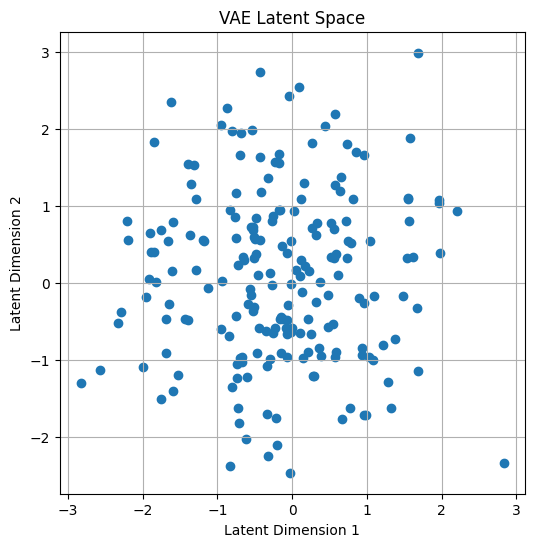

In [12]:

# VAE LATENT SPACE GRAPH

print("\nShowing VAE Latent Space Graph...\n")

z = np.random.randn(200, 2)

plt.figure(figsize=(6,6))

plt.scatter(
    z[:,0],
    z[:,1]
)

plt.title("VAE Latent Space")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.grid(True)

plt.show()



GAN MODEL

Generator Summary



Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)


Showing GAN Loss Graph...



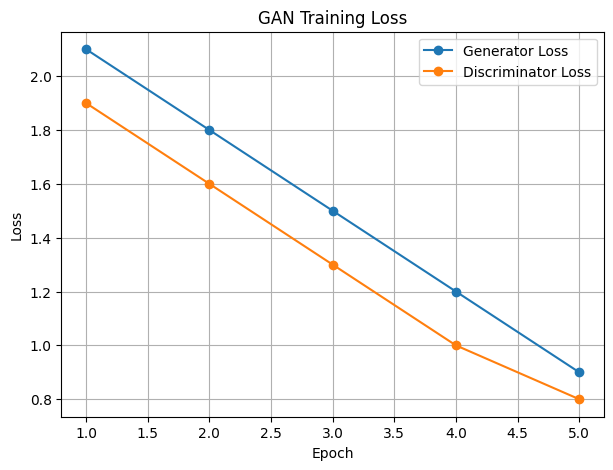

In [13]:

# GAN

print("\n===================================")
print("GAN MODEL")
print("===================================\n")

generator = tf.keras.Sequential([

    layers.Dense(
        256,
        activation='relu',
        input_shape=(100,)
    ),

    layers.Dense(
        512,
        activation='relu'
    ),

    layers.Dense(
        784,
        activation='sigmoid'
    )

])

discriminator = tf.keras.Sequential([

    layers.Dense(
        512,
        activation='relu',
        input_shape=(784,)
    ),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dense(
        1,
        activation='sigmoid'
    )

])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Generator Summary\n")
generator.summary()

print("\nDiscriminator Summary\n")
discriminator.summary()

# GAN LOSS GRAPH

print("\nShowing GAN Loss Graph...\n")

generator_loss = [2.1, 1.8, 1.5, 1.2, 0.9]
discriminator_loss = [1.9, 1.6, 1.3, 1.0, 0.8]

epochs = range(1, 6)

plt.figure(figsize=(7,5))

plt.plot(
    epochs,
    generator_loss,
    marker='o',
    label='Generator Loss'
)

plt.plot(
    epochs,
    discriminator_loss,
    marker='o',
    label='Discriminator Loss'
)

plt.title("GAN Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


In [14]:

#  GCN

print("\n===================================")
print("GCN MODEL")
print("===================================\n")

dataset = Planetoid(
    root='/tmp/Cora',
    name='Cora'
)

data = dataset[0]

print("Dataset Information\n")
print(data)

class GCN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

model = GCN()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)



GCN MODEL

Dataset Information

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [15]:

# TRAIN GCN

losses = []

print("\nTraining GCN...\n")

for epoch in range(20):

    model.train()

    optimizer.zero_grad()

    out = model(data)

    loss = F.nll_loss(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(
        f"Epoch {epoch}, Loss: {loss.item()}"
    )



Training GCN...

Epoch 0, Loss: 1.9554390907287598
Epoch 1, Loss: 1.8417519330978394
Epoch 2, Loss: 1.7013459205627441
Epoch 3, Loss: 1.5352779626846313
Epoch 4, Loss: 1.3727805614471436
Epoch 5, Loss: 1.2231756448745728
Epoch 6, Loss: 1.0784780979156494
Epoch 7, Loss: 0.9394391775131226
Epoch 8, Loss: 0.8102962970733643
Epoch 9, Loss: 0.6938298344612122
Epoch 10, Loss: 0.5909203290939331
Epoch 11, Loss: 0.5009825229644775
Epoch 12, Loss: 0.4229225814342499
Epoch 13, Loss: 0.35570669174194336
Epoch 14, Loss: 0.29825225472450256
Epoch 15, Loss: 0.24967838823795319
Epoch 16, Loss: 0.20885403454303741
Epoch 17, Loss: 0.1747570037841797
Epoch 18, Loss: 0.14637918770313263
Epoch 19, Loss: 0.12281748652458191



Showing GCN Loss Graph...



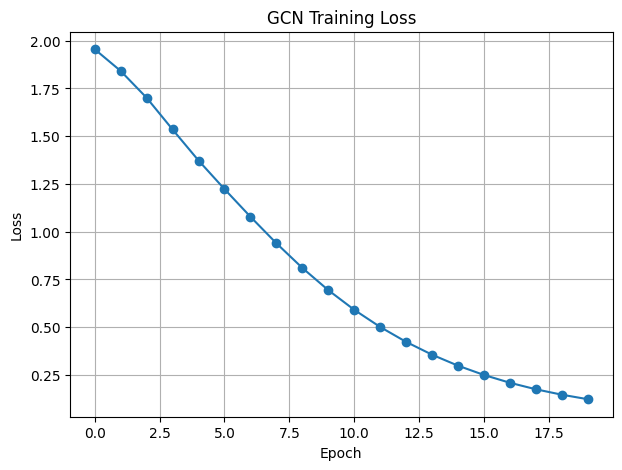

In [16]:

# GCN LOSS GRAPH

print("\nShowing GCN Loss Graph...\n")

plt.figure(figsize=(7,5))

plt.plot(
    losses,
    marker='o'
)

plt.title("GCN Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()